# 01 — EDA и baseline-оценка

Ноутбук выполняет анализ датасета Gazeta и считает экстрактивные baseline-модели.
Общая постановка задачи, итоговые метрики и сравнительные выводы вынесены в `README.md`.

In [1]:
!pip -q install evaluate rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:

# ==== Common setup (runs on Kaggle) ====
import os, re, json, random, math
from pathlib import Path

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

WORKDIR = Path("/kaggle/working")
WORKDIR.mkdir(parents=True, exist_ok=True)

print("Kaggle input dirs:", [p.name for p in Path("/kaggle/input").glob("*")])


Kaggle input dirs: ['datasets']


In [3]:

# ==== Robust Gazeta loader ====
import pandas as pd
from pathlib import Path

def _find_dataset_root():
    inp = Path("/kaggle/input")
    # If you attached only the Gazeta dataset, it will be one folder.
    # If you have multiple, we pick the one that contains 'gazeta' in name, else the biggest.
    dirs = [d for d in inp.iterdir() if d.is_dir()]
    if not dirs:
        raise FileNotFoundError("No datasets found in /kaggle/input. Attach the Gazeta dataset in Kaggle first.")
    gaz = [d for d in dirs if "gazeta" in d.name.lower()]
    if gaz:
        return gaz[0]
    # fallback: pick dir with most files
    return max(dirs, key=lambda d: sum(1 for _ in d.rglob("*") if _.is_file()))

def _pick_text_and_summary_cols(df):
    # Try common names first
    candidates_text = ["text", "article", "body", "content", "news", "document"]
    candidates_sum  = ["summary", "target", "abstract", "lead", "highlights"]
    cols = [c for c in df.columns if df[c].dtype == "object"]
    low = {c.lower(): c for c in df.columns}

    for c in candidates_text:
        if c in low: 
            text_col = low[c]; break
    else:
        # Heuristic: choose object col with highest avg length
        text_col = max(cols, key=lambda c: df[c].fillna("").astype(str).str.len().mean())

    for c in candidates_sum:
        if c in low:
            sum_col = low[c]; break
    else:
        # Heuristic: choose object col with lowest avg length among object cols != text_col
        other = [c for c in cols if c != text_col]
        if not other:
            raise ValueError("Could not infer summary column. Columns: " + ", ".join(df.columns))
        sum_col = min(other, key=lambda c: df[c].fillna("").astype(str).str.len().mean())

    return text_col, sum_col

def load_gazeta_splits():
    root = _find_dataset_root()
    files = list(root.rglob("*.csv")) + list(root.rglob("*.tsv")) + list(root.rglob("*.parquet")) + list(root.rglob("*.jsonl"))
    if not files:
        raise FileNotFoundError(f"No data files found under {root}. Found only: {[p.name for p in root.rglob('*')][:20]}")
    # Prefer train/test by filename
    def score(p):
        n = p.name.lower()
        s = 0
        if "train" in n: s += 3
        if "test" in n: s += 2
        if "val" in n or "valid" in n or "dev" in n: s += 1
        return s
    files_sorted = sorted(files, key=lambda p: (score(p), p.stat().st_size), reverse=True)

    # Load all files, then pick train/test heuristically
    frames = []
    for p in files_sorted[:6]:  # usually enough
        try:
            if p.suffix == ".parquet":
                df = pd.read_parquet(p)
            elif p.suffix == ".jsonl":
                df = pd.read_json(p, lines=True)
            elif p.suffix == ".tsv":
                df = pd.read_csv(p, sep="\t")
            else:
                df = pd.read_csv(p)
            df["_source_file"] = p.name
            frames.append(df)
        except Exception as e:
            print("Skip", p, "->", type(e).__name__, e)

    if not frames:
        raise RuntimeError("Could not load any dataset file. Check file formats in /kaggle/input.")

    # If dataset already has split column, use it
    df = pd.concat(frames, ignore_index=True)
    text_col, sum_col = _pick_text_and_summary_cols(df)
    print("Inferred columns:", {"text": text_col, "summary": sum_col})
    print("Example rows:\n", df[[text_col, sum_col]].head(2))

    # Try to separate by file names
    train_df = df[df["_source_file"].str.contains("train", case=False, na=False)]
    test_df  = df[df["_source_file"].str.contains("test",  case=False, na=False)]
    valid_df = df[df["_source_file"].str.contains("val|valid|dev", case=False, na=False, regex=True)]

    if len(train_df) > 0 and len(test_df) > 0:
        pass
    else:
        # fallback: random split
        df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        n = len(df)
        train_df = df.iloc[: int(0.9*n)]
        test_df  = df.iloc[int(0.9*n):]
        valid_df = df.iloc[int(0.85*n): int(0.9*n)]

    # Cleanup + rename
    def clean(x): 
        return str(x).replace("\xa0"," ").strip()

    train = train_df[[text_col, sum_col]].rename(columns={text_col:"text", sum_col:"summary"}).dropna()
    valid = valid_df[[text_col, sum_col]].rename(columns={text_col:"text", sum_col:"summary"}).dropna()
    test  = test_df [[text_col, sum_col]].rename(columns={text_col:"text", sum_col:"summary"}).dropna()

    train["text"] = train["text"].map(clean); train["summary"] = train["summary"].map(clean)
    valid["text"] = valid["text"].map(clean); valid["summary"] = valid["summary"].map(clean)
    test ["text"] = test ["text"].map(clean); test ["summary"] = test ["summary"].map(clean)

    print("Split sizes:", {"train":len(train), "valid":len(valid), "test":len(test)})
    return train, valid, test

train_df, valid_df, test_df = load_gazeta_splits()


Inferred columns: {'text': 'text', 'summary': 'summary'}
Example rows:
                                                 text  \
0  Сегодня транспортный налог начисляется в завис...   
1  Словосочетание «музыкальный кинофестиваль» уже...   

                                             summary  
0  С 2011 года правительство отменяет самый раздр...  
1  Британские затворники, московские модники, бра...  
Split sizes: {'train': 60964, 'valid': 6369, 'test': 6793}


train: n=60,964 text_len mean=4525.3 p95=7073 | sum_len mean=310.9 p95=451
valid: n=6,369 text_len mean=4358.4 p95=7188 | sum_len mean=335.6 p95=463
test: n=6,793 text_len mean=4446.1 p95=7498 | sum_len mean=343.4 p95=477


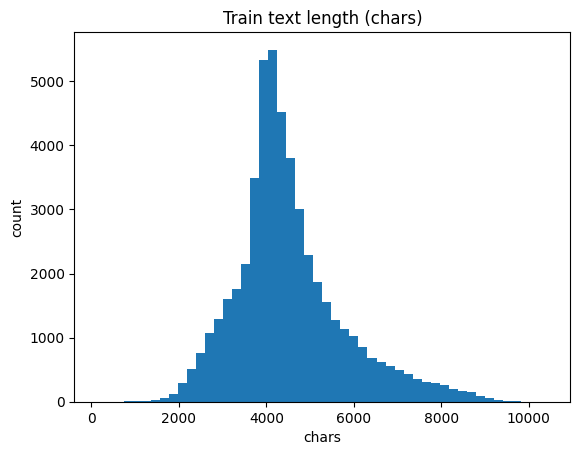

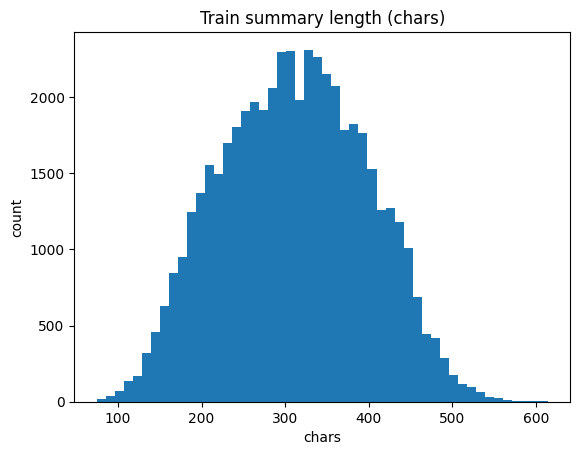

In [4]:

# ==== EDA ====
import numpy as np
import matplotlib.pyplot as plt

def lengths(df):
    return df["text"].str.len().values, df["summary"].str.len().values

for name, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    tlen, slen = lengths(df)
    print(f"{name}: n={len(df):,} text_len mean={tlen.mean():.1f} p95={np.percentile(tlen,95):.0f} | "
          f"sum_len mean={slen.mean():.1f} p95={np.percentile(slen,95):.0f}")

# Simple plots (first 50k points max for speed)
sample = train_df.sample(n=min(len(train_df), 50000), random_state=SEED)
tlen = sample["text"].str.len().values
slen = sample["summary"].str.len().values

plt.figure()
plt.hist(tlen, bins=50)
plt.title("Train text length (chars)")
plt.xlabel("chars"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(slen, bins=50)
plt.title("Train summary length (chars)")
plt.xlabel("chars"); plt.ylabel("count")
plt.show()


In [5]:

# ==== Baselines (first / last / first+last sentence) ====
import re

_SENT_SPLIT = re.compile(r'(?<=[\.\!\?])\s+')

def sent_split(text: str):
    sents = _SENT_SPLIT.split(text.strip())
    sents = [s.strip() for s in sents if s.strip()]
    return sents

def baseline_first(text):
    s = sent_split(text)
    return s[0] if s else ""

def baseline_last(text):
    s = sent_split(text)
    return s[-1] if s else ""

def baseline_first_last(text):
    s = sent_split(text)
    if not s: return ""
    if len(s) == 1: return s[0]
    return (s[0] + " " + s[-1]).strip()

# Quick sanity
print(train_df.iloc[0]["text"][:300])
print("FIRST:", baseline_first(train_df.iloc[0]["text"]))
print("LAST :", baseline_last(train_df.iloc[0]["text"]))
print("BOTH :", baseline_first_last(train_df.iloc[0]["text"]))


Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек. Также ставку налога могут корректировать региональные власти: согласно Налоговому кодексу, базовый тариф, установленный правительством, может быть уменьшен в пять 
FIRST: Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек.
LAST : Как предполагается распределять деньги между регионами и федеральным дорожным агентством и кто будет следить за потоками, в правительстве пока не решили.
BOTH : Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек. Как предполагается распределять деньги между регионами и федеральным дорожным агентством и кто будет следить за потоками, в правительстве пока не решили.


In [6]:

# ==== ROUGE evaluation on a small, stable subset ====
import evaluate
rouge = evaluate.load("rouge")

EVAL_N = min(1000, len(test_df))
eval_df = test_df.sample(n=EVAL_N, random_state=SEED).reset_index(drop=True)

refs = eval_df["summary"].tolist()
pred_first = [baseline_first(t) for t in eval_df["text"]]
pred_last  = [baseline_last(t) for t in eval_df["text"]]
pred_both  = [baseline_first_last(t) for t in eval_df["text"]]

def rouge_scores(preds, refs):
    out = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: float(out[k]) for k in ["rouge1","rouge2","rougeL","rougeLsum"] if k in out}

scores = {
    "first_sentence": rouge_scores(pred_first, refs),
    "last_sentence": rouge_scores(pred_last, refs),
    "first+last": rouge_scores(pred_both, refs)
}
scores


{'first_sentence': {'rouge1': 0.18272821514234566,
  'rouge2': 0.06373466255966254,
  'rougeL': 0.18030370462870465,
  'rougeLsum': 0.18003000827674753},
 'last_sentence': {'rouge1': 0.03273733766233766,
  'rouge2': 0.012166666666666668,
  'rougeL': 0.03308813131313131,
  'rougeLsum': 0.0329424963924964},
 'first+last': {'rouge1': 0.17300632858115705,
  'rouge2': 0.05797040345275637,
  'rougeL': 0.17061451779214953,
  'rougeLsum': 0.17013233869486746}}

In [7]:

# Save baseline results
import json
out_path = WORKDIR / "baseline_rouge.json"
out_path.write_text(json.dumps(scores, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_path)


Saved: /kaggle/working/baseline_rouge.json


## Мини-вывод
Сохрани результаты из `baseline_rouge.json` — они понадобятся в финальном сравнении.